In [5]:
import os

os.listdir()

['.config', 'face-mask-12k-images-dataset.zip', 'sample_data']

#**EDA & Visualizer**

In [7]:
os.listdir("dataset")

['Face Mask Dataset']

In [8]:
import os

os.listdir("dataset/Face Mask Dataset")

['Train', 'Validation', 'Test']

In [9]:
data_dir="dataset/Face Mask Dataset"
train_dir = "dataset/Face Mask Dataset/Train"
val_dir   = "dataset/Face Mask Dataset/Validation"
test_dir  = "dataset/Face Mask Dataset/Test"

In [10]:

import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import random

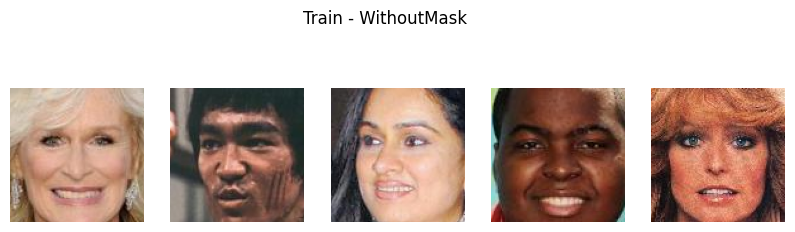

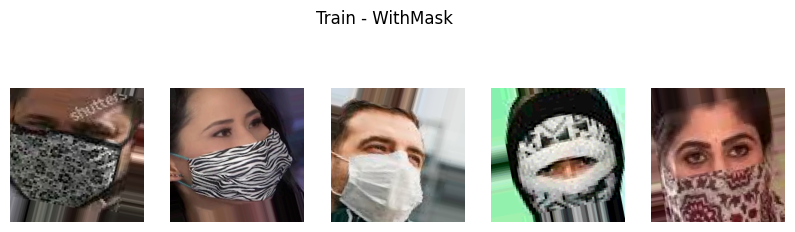

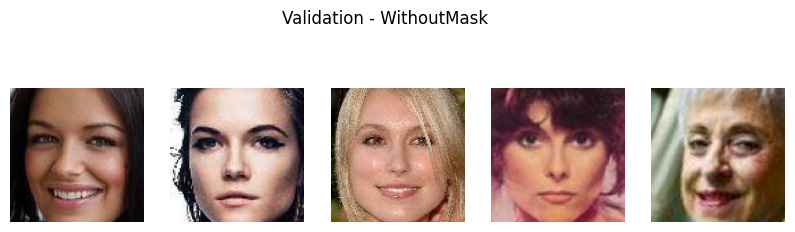

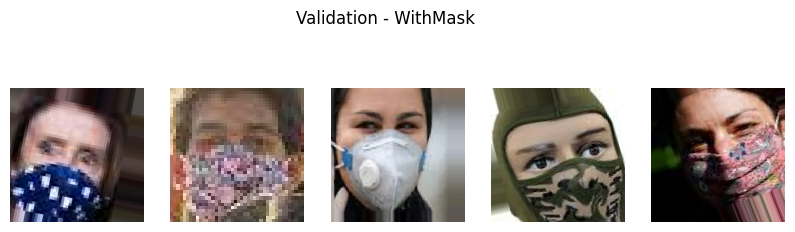

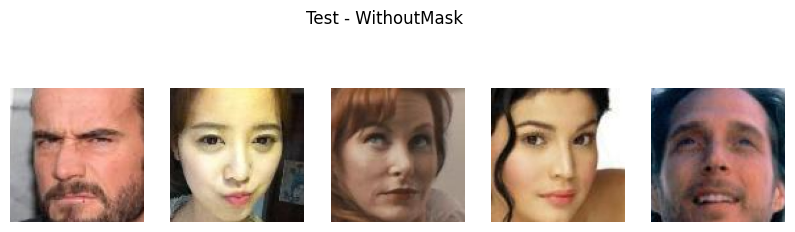

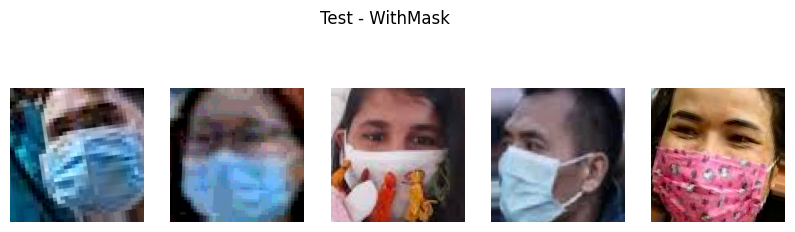

In [11]:
num_samples=5
for split in os.listdir(data_dir):
    split_path = os.path.join(data_dir, split)
    if not os.path.isdir(split_path):
        continue

    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if not os.path.isdir(class_path):
            continue

        images = [
            os.path.join(class_path, img)
            for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if len(images) == 0:
            continue

        plt.figure(figsize=(10, 3))
        plt.suptitle(f"{split} - {cls}")
        for i in range(min(5, len(images))):
            img = plt.imread(random.choice(images))

            plt.subplot(1, num_samples, i+1)
            plt.imshow(img)
            plt.axis('off')

        plt.show()

### **Sample of Data** : This data have two class : WithMask , WithoutMask ,split in three folder 1- Train 2- Validation 3- Test

In [12]:
import os

def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)
        if os.path.isdir(class_path):
            counts[cls] = len(os.listdir(class_path))
    return counts

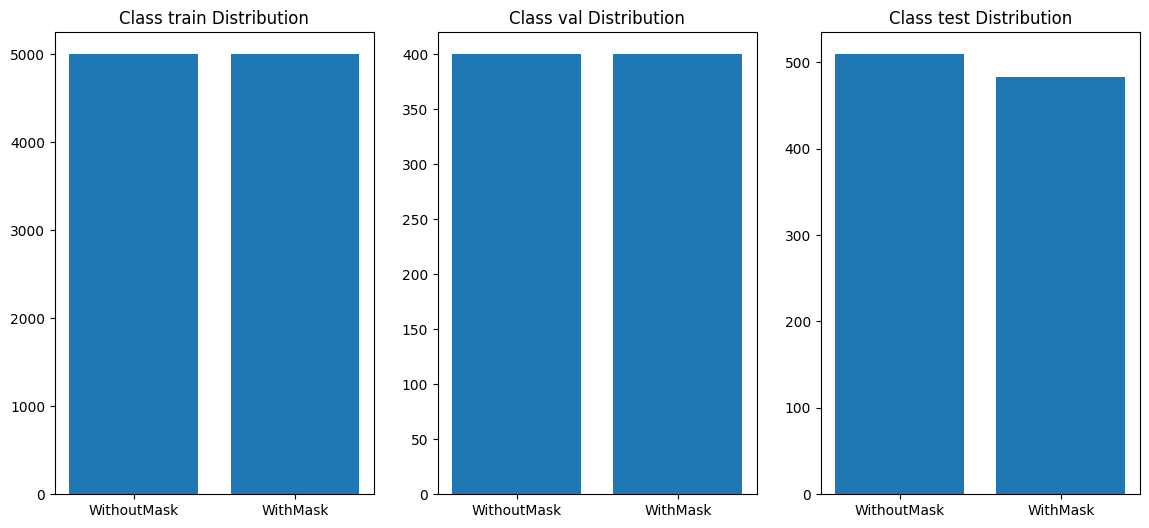

In [13]:
import matplotlib.pyplot as plt

counts_train = count_images(train_dir)
counts_test = count_images(test_dir)
counts_val = count_images(val_dir)

fig,axes=plt.subplots(1,3,figsize=(14,6))

axes[0].bar(counts_train.keys(),counts_train.values())
axes[0].set_title("Class train Distribution")

axes[1].bar(counts_val.keys(),counts_val.values())
axes[1].set_title("Class val Distribution")

axes[2].bar(counts_test.keys(),counts_test.values())
axes[2].set_title("Class test Distribution")

plt.show()


The count of image in set train & val are balanced but slight variance in test set

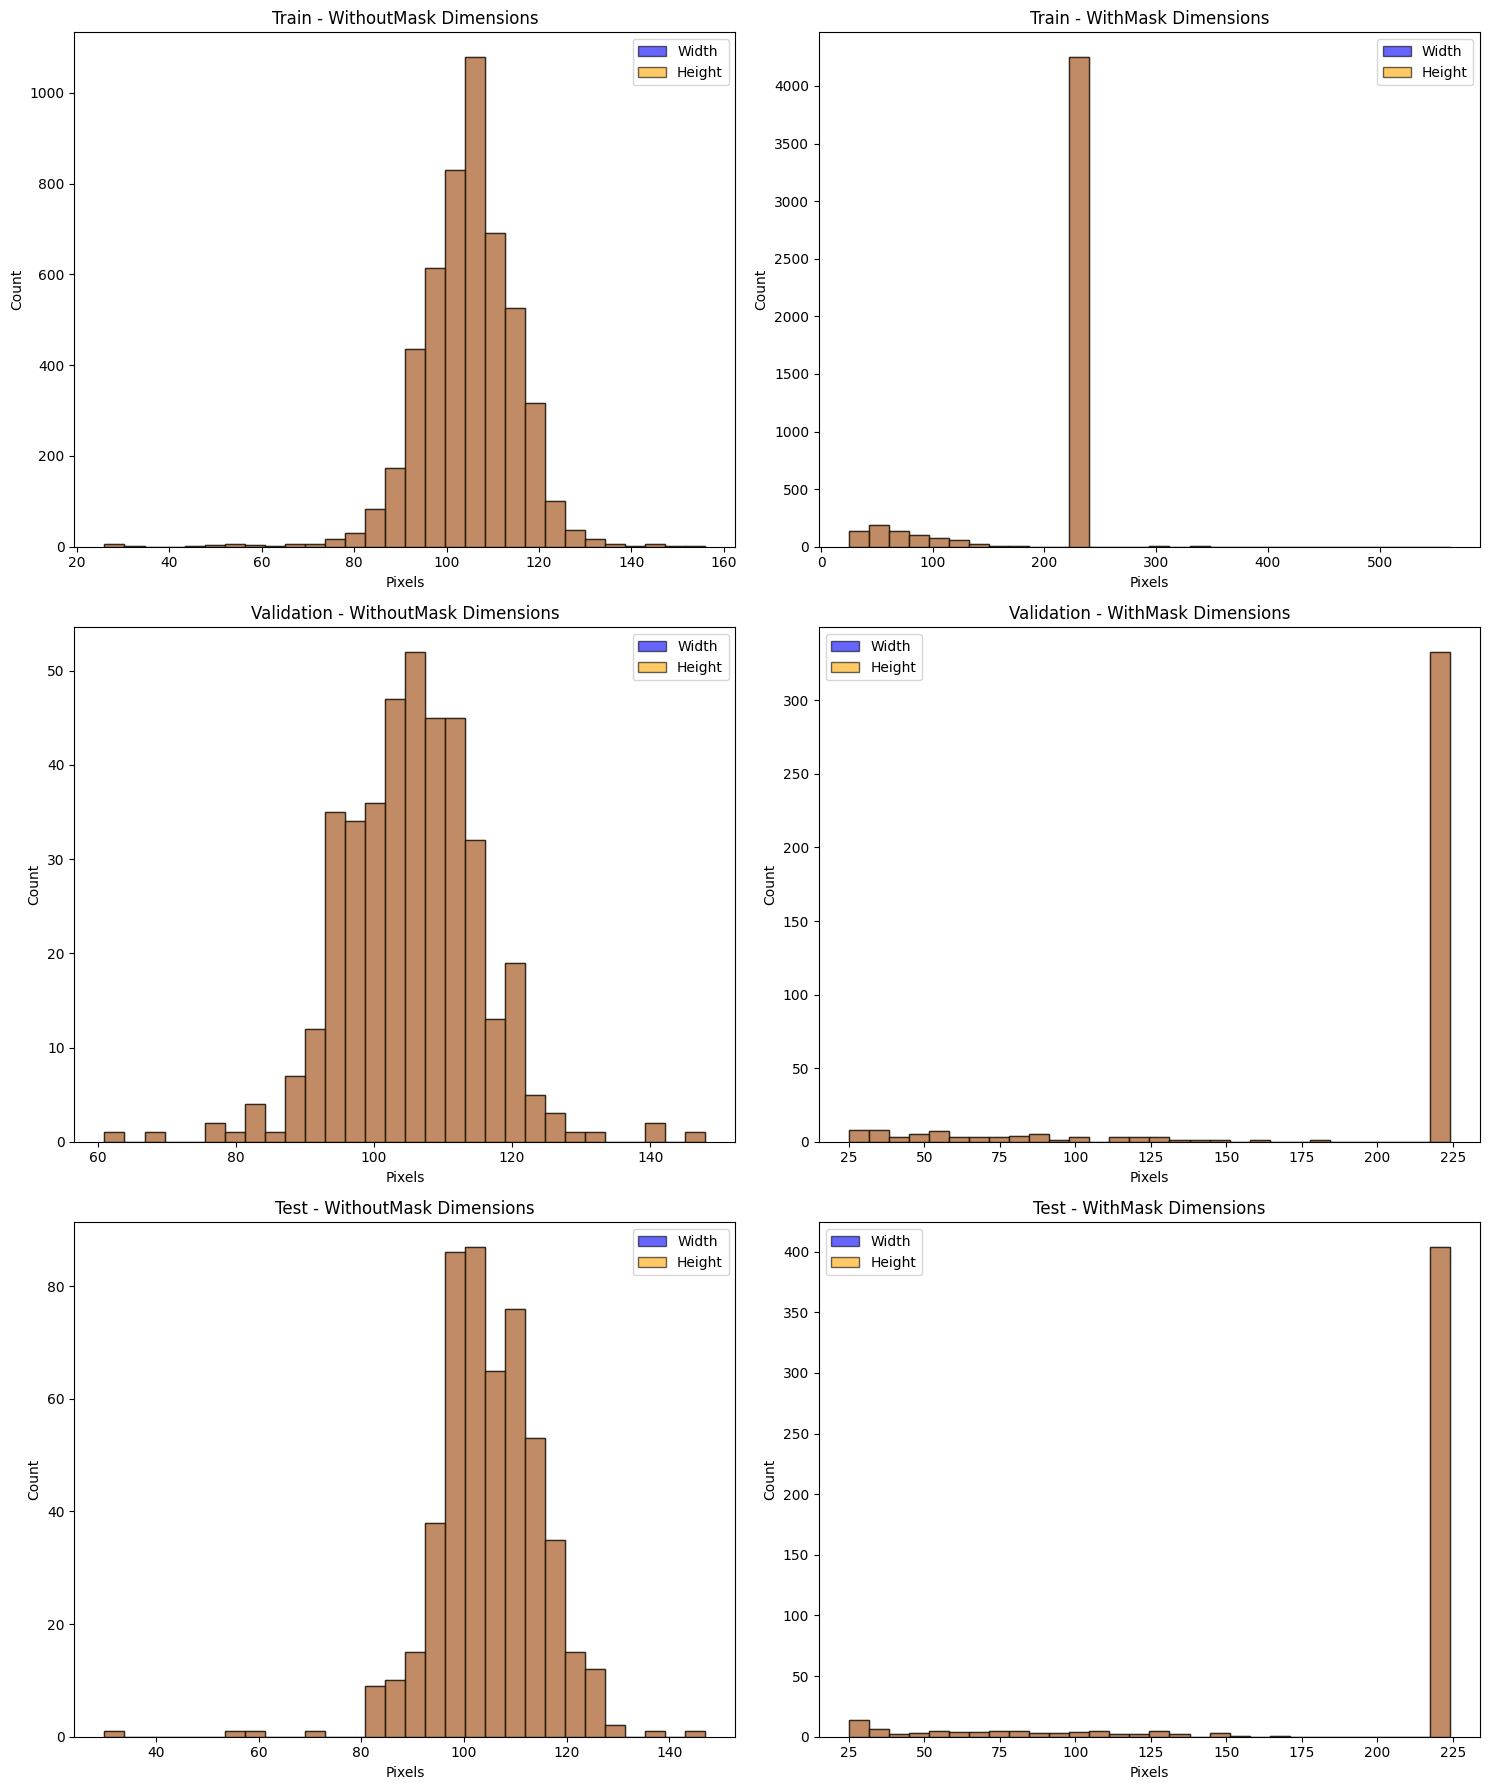

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

dataset_path = "../data/Face Mask Dataset"
data_sets = ['Train', 'Validation', 'Test']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

for row, set_name in enumerate(data_sets):
    set_path = os.path.join(dataset_path, set_name)

    if not os.path.exists(set_path):
        continue

    classes = [d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))]

    for col, class_name in enumerate(classes):
        class_path = os.path.join(set_path, class_name)
        widths = []
        heights = []

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)

        axes[row, col].hist(widths, bins=30, alpha=0.6, label='Width', color='blue', edgecolor='black')
        axes[row, col].hist(heights, bins=30, alpha=0.6, label='Height', color='orange', edgecolor='black')

        axes[row, col].set_title(f"{set_name} - {class_name} Dimensions")
        axes[row, col].set_xlabel("Pixels")
        axes[row, col].set_ylabel("Count")
        axes[row, col].legend()

plt.tight_layout()
plt.show()

 **Image Dimensions Analysis Uniformity**: The majority of images in the WithMask category are standardized at 224x224 pixels.

**Variability**: The WithoutMask category shows a normal distribution of sizes, centered around 100-110 pixels.

**Consistency**: The height and width for each image are identical, confirming a 1:1 Aspect Ratio across the dataset

In [15]:
def get_image_brightness(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

In [16]:
def get_dataset_brightness(folder):
    brightness_values = {}

    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        if os.path.isdir(class_path):
            values = []

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                try:
                    b = get_image_brightness(img_path)
                    values.append(b)
                except:
                    continue

            if len(values) > 0:
                brightness_values[cls] = values

    return brightness_values

In [17]:
result_train = get_dataset_brightness(train_dir)
result_val = get_dataset_brightness(val_dir)
result_test = get_dataset_brightness(test_dir)
data_train = []
data_val=[]
data_test=[]

for cls, values in result_train.items():
    for v in values:
        data_train.append([cls, v])
df_train = pd.DataFrame(data_train, columns=["class", "brightness"])

for cls, values in result_val.items():
    for v in values:
        data_val.append([cls, v])
df_val = pd.DataFrame(data_val, columns=["class", "brightness"])

for cls, values in result_test.items():
    for v in values:
        data_test.append([cls, v])
df_test = pd.DataFrame(data_test, columns=["class", "brightness"])


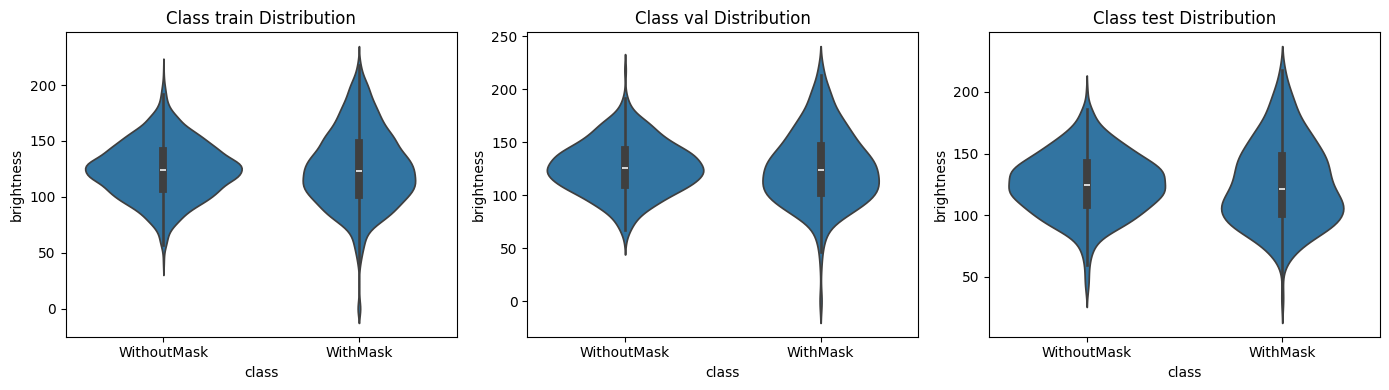

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.violinplot(x='class', y='brightness', data=df_train, ax=axes[0])
axes[0].set_title("Class train Distribution")

sns.violinplot(x='class', y='brightness', data=df_val, ax=axes[1])
axes[1].set_title("Class val Distribution")

sns.violinplot(x='class', y='brightness', data=df_test, ax=axes[2])
axes[2].set_title("Class test Distribution")

plt.tight_layout()
plt.show()

**Consistency**: The brightness distribution is nearly identical across Train, Val, and Test sets.

**Central Tendency**: Most images have a mean brightness centered around 100–125.

**Class Comparison**: The WithMask class shows a slightly wider spread and more outliers toward lower brightness levels compared to WithoutMask

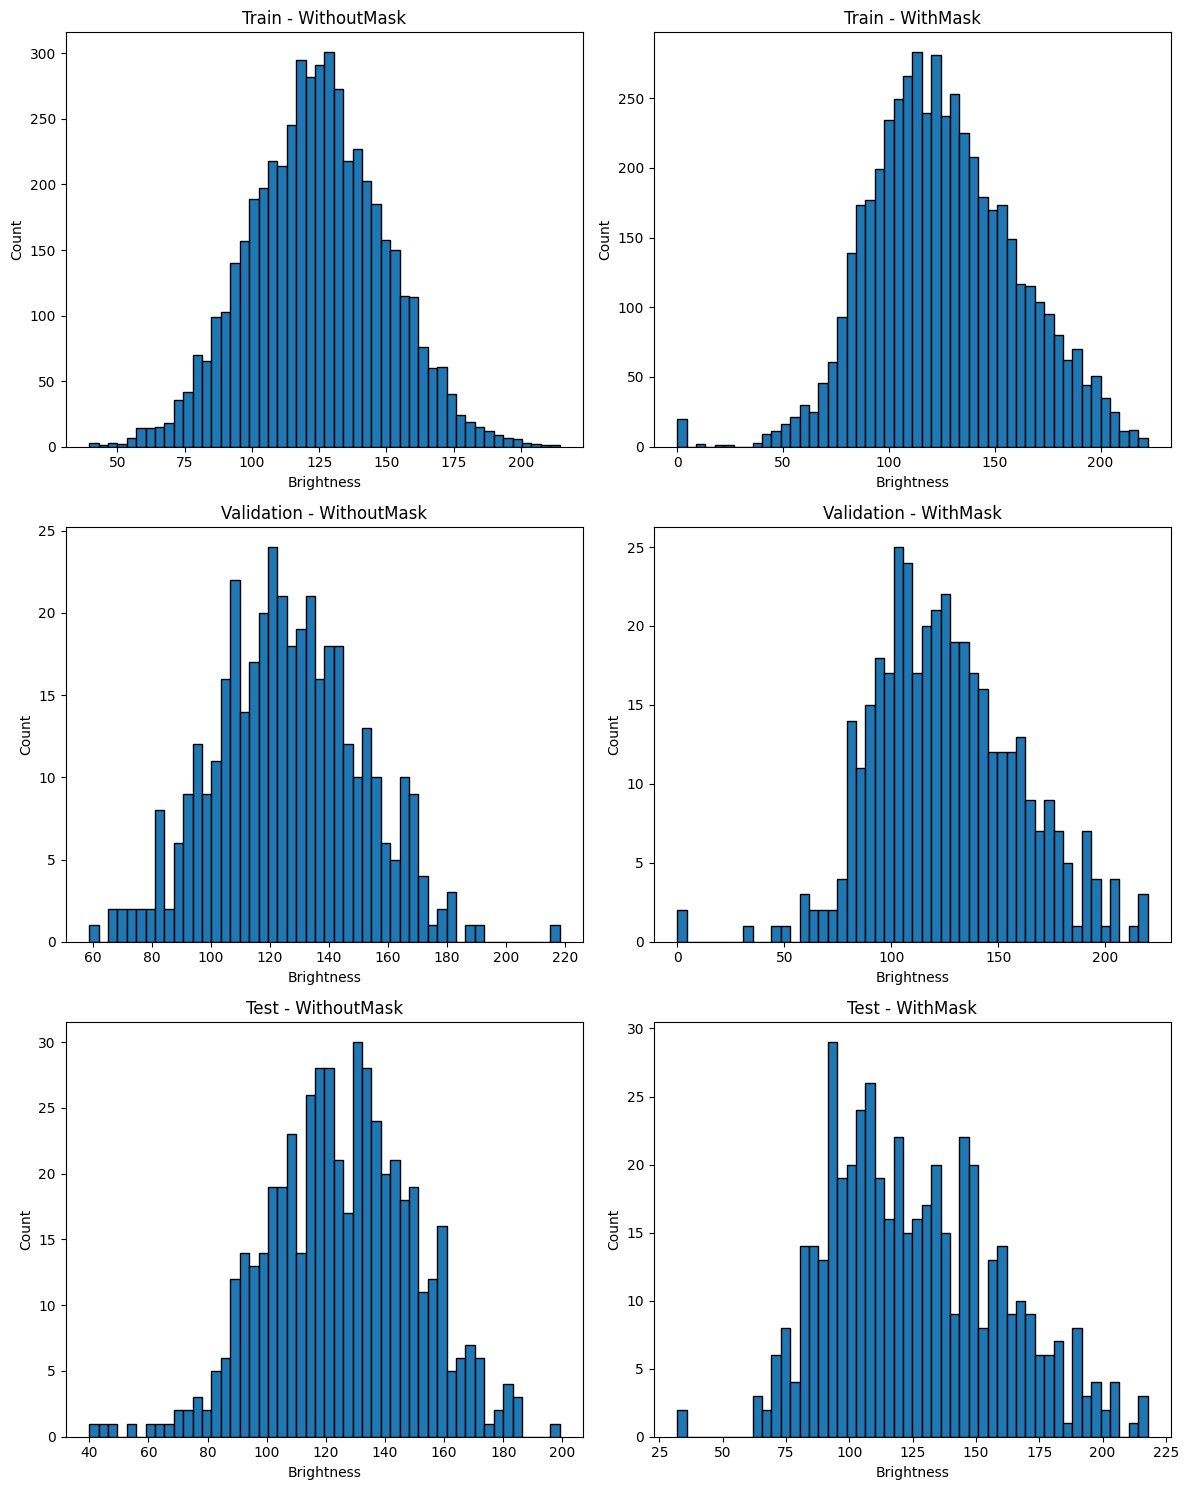

In [ ]:

dataset_path = "../data/Face Mask Dataset"
data_sets = ['Train', 'Validation', 'Test']

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row, set_name in enumerate(data_sets):
    set_path = os.path.join(dataset_path, set_name)

    if not os.path.exists(set_path):
        continue

    classes = [d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))]

    for col, class_name in enumerate(classes):
        class_path = os.path.join(set_path, class_name)
        brightness_values = []

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness = np.mean(gray)
            brightness_values.append(brightness)

        axes[row, col].hist(brightness_values, bins=50, edgecolor='black')
        axes[row, col].set_title(f"{set_name} - {class_name}")
        axes[row, col].set_xlabel("Brightness")
        axes[row, col].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Normal Distribution**: Both classes across all splits follow a Gaussian-like distribution.

**Mean Centering**: Most images peak between 100 and 130 on the brightness scale.


In [20]:
def calculate_blur(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

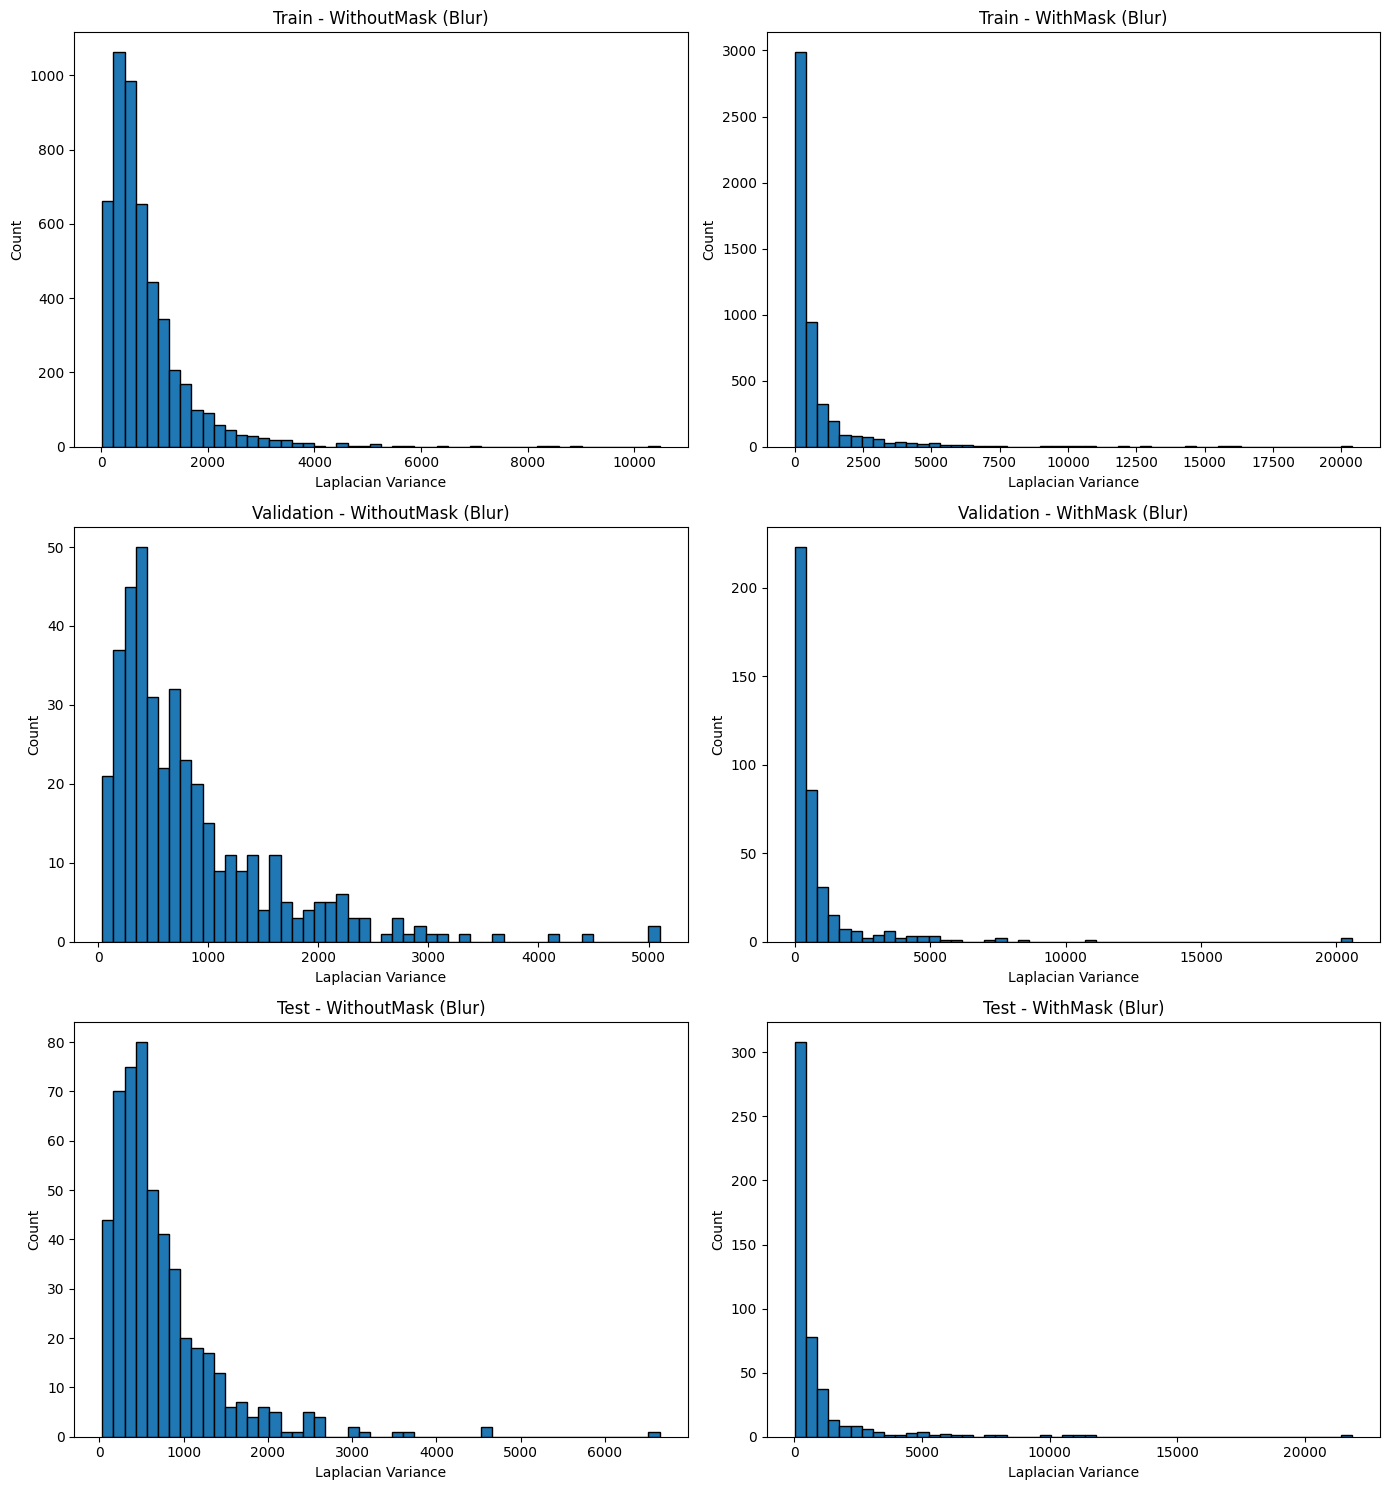

In [ ]:
dataset_path = "../data/Face Mask Dataset"
data_sets = ['Train', 'Validation', 'Test']

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row, set_name in enumerate(data_sets):
    set_path = os.path.join(dataset_path, set_name)

    if not os.path.exists(set_path):
        continue


    classes = [d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))]

    for col, class_name in enumerate(classes):
        class_path = os.path.join(set_path, class_name)
        blur_values = []

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            blur_val = calculate_blur(img)
            blur_values.append(blur_val)
        axes[row, col].hist(blur_values, bins=50,edgecolor='black')
        axes[row, col].set_title(f"{set_name} - {class_name} (Blur)")
        axes[row, col].set_xlabel("Laplacian Variance")
        axes[row, col].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Positive Skewness**: All splits exhibit a long-tail distribution skewed toward lower variance values. This indicates that a vast majority of the dataset consists of relatively smooth/blurry images, with only a few very sharp outliers.

**Distinct Class Profiles**: * WithoutMask: Shows a "fatter" distribution with many images between 500–1000 variance.

WithMask: Shows a much steeper peak near zero, but with an extremely long tail reaching 20,000+. This implies images with masks are either very soft or contain very high-contrast edges (likely from mask patterns or edges).

